# 12 · Curve fitting and property regression (refreshed classic)

*Two ways to turn a curve into a number: physics, and machine learning.*

> ⏱ **Runtime:** ~5 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** raw curves + AFM grid

### 🎯 What you'll learn
1. **physics fitting**: fit the loading curve to Kick's law P = C·hⁿ and read off the coefficients,
2. **regression**: predict hardness from curve features with a Random-Forest **regressor**,
3. how to read a **parity plot** and **R²** to judge a regression honestly,
4. when a physical model and a machine-learning model each make sense.

### 🧭 What you need to know first
- The idea of a load–depth curve (notebook 00) and feature importance (notebook 03).
- Curve features come from `mm.curve_scalar_features` (in the helper package).

> 🧭 **Classification vs regression.** Earlier notebooks predicted a **category** (which phase) —
> that's *classification*. Here we predict a **number** (hardness in GPa) — that's **regression**.
> Same spirit, but we measure success differently (with R², not accuracy).

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
print("helpers loaded from:", mm.__file__)

helpers loaded from: C:\Users\edrossi.PERSONALE\Dropbox\Meca Nano Live tutorials\Tutorial1_repo_update\mecanano-ml-nanomechanics\src\mecanano_ml\__init__.py


In [2]:
from scipy.optimize import curve_fit                # non-linear least-squares fitting
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

## 1 · Physics: fit P = C·hⁿ (Kick's law)

The loading branch of an elastic–plastic indent follows a **power law** P = C·hⁿ (Kick's law). For
a geometrically self-similar tip the exponent **n ≈ 2**. Fitting recovers `C` and `n` directly from one curve.

> 🧠 **curve fitting** — finding the parameters (here C and n) that make a chosen formula match the data as closely as possible. `scipy.optimize.curve_fit` does the least-squares work.

> ✅ **When you run the next cell, you should see:** a curve with the fitted power law overlaid in red, and printed **C** and **n ≈ 1.9** (close to the theoretical 2).

C = 2.471e-04,  n = 1.89


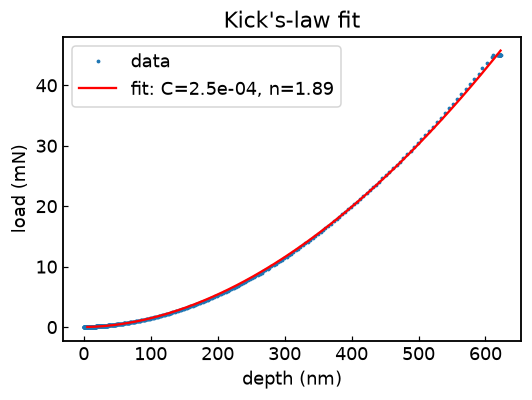

In [3]:
d, l = mm.load_curves(1)[0]                          # one raw curve: depth d, load l
k = int(np.argmax(l)); h, P = d[:k + 1], l[:k + 1]   # keep the loading branch (up to max load)
m = (h > 5) & (P > 0)                                 # skip the noisy near-surface region

# Fit P = C * h**n for unknowns C, n (p0 = starting guess).
popt, _ = curve_fit(lambda h, C, n: C * h ** n, h[m], P[m], p0=[1e-3, 2], maxfev=10000)
C, n = popt

fig, ax = plt.subplots(figsize=(5, 3.8))
ax.plot(h, P, ".", ms=3, label="data")
hh = np.linspace(h[m].min(), h.max(), 200)
ax.plot(hh, C * hh ** n, "r-", label=f"fit: C={C:.1e}, n={n:.2f}")
ax.set_xlabel("depth (nm)"); ax.set_ylabel("load (mN)"); ax.legend()
ax.set_title("Kick's-law fit"); fig.tight_layout()
print(f"C = {C:.3e},  n = {n:.2f}")

*🖼 **Figure.** The red power law hugs the data, and the fitted exponent n is near 2 — the physics model works and its coefficients are directly interpretable.*

## 2 · Machine learning: predict hardness from the curve

Now a data-driven route. For every indent on the AFM grid we compute a few **descriptors** of its
load–depth curve, then train a regressor to predict **hardness**. The parity plot and R² tell us how
much of the property the curve shape actually carries.

> 🧠 **regressor** — a model that predicts a continuous number (here hardness) rather than a category.

> ✅ **When you run the next cell, you should see:** the number of usable indents and the list of curve features (P_max, h_max, stiffness S, work ratio, curvature C).

In [4]:
afm = mm.load_afm_grid()
depth = afm["depth_nm"]; loadc = afm["load_mN"]
rows = []
for i in range(loadc.shape[0]):
    # compact physical descriptors of each curve (max load, stiffness, work ratio, ...)
    rows.append(mm.curve_scalar_features(depth, loadc[i]))
F = pd.DataFrame(rows)
y = afm["H"]
ok = np.isfinite(F.values).all(1) & np.isfinite(y)   # keep only fully-finite rows
F, y = F[ok], y[ok]
print("usable indents:", len(F), " features:", list(F.columns))

usable indents: 828  features: ['P_max', 'h_max', 'S', 'We_Wt', 'C']


> 🧠 **parity plot** — predicted value vs measured value, with a diagonal line. Points hugging the diagonal = good predictions; scatter away from it = errors.

> 🧠 **R² (coefficient of determination)** — the fraction of the variation the model explains: 1.0 = perfect, 0 = no better than always guessing the mean. Around 0.8 here means the curve shape carries most, not all, of the hardness.

> ✅ **When you run the next cell, you should see:** left: a parity plot with points near the diagonal and **R² ≈ 0.8**; right: which curve features the model leaned on.

R² = 0.802


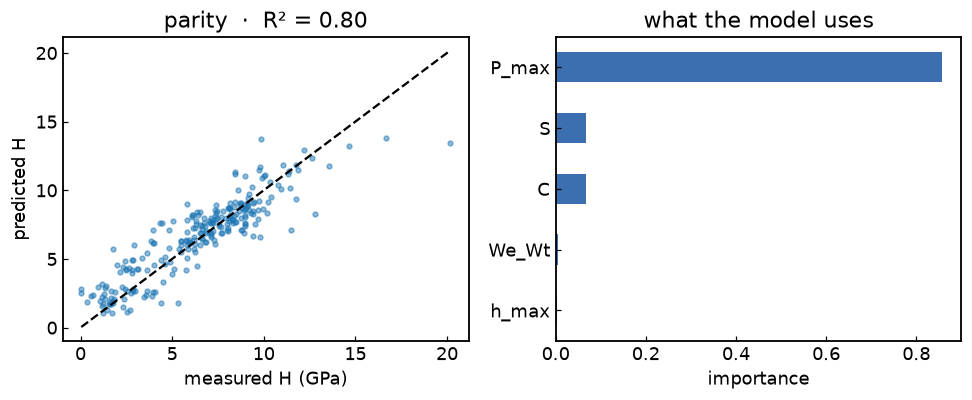

In [5]:
Xtr, Xte, ytr, yte = train_test_split(F.values, y, test_size=0.3, random_state=0)
reg = RandomForestRegressor(300, random_state=0, n_jobs=-1).fit(Xtr, ytr)
pred = reg.predict(Xte)
r2 = r2_score(yte, pred)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].scatter(yte, pred, s=10, alpha=.5)
lim = [min(yte.min(), pred.min()), max(yte.max(), pred.max())]
ax[0].plot(lim, lim, "k--")                          # the perfect-prediction diagonal
ax[0].set_xlabel("measured H (GPa)"); ax[0].set_ylabel("predicted H")
ax[0].set_title(f"parity  ·  R² = {r2:.2f}")
imp = pd.Series(reg.feature_importances_, index=F.columns).sort_values()
imp.plot.barh(ax=ax[1], color="#3b6fb0"); ax[1].set_xlabel("importance"); ax[1].set_title("what the model uses")
fig.tight_layout()
print("R² =", round(r2, 3))

*🖼 **Figure.** Predictions cluster around the dashed diagonal (R² ≈ 0.8): the curve shape predicts most of the hardness, but not all — the honest verdict a parity plot gives you.*

## ✅ Recap
- **Physics fits** give interpretable coefficients (C, n) straight from a curve — use them when a law is known.
- A **Random-Forest regressor** learns a property from curve descriptors; the **parity plot / R²** keep you honest about what the curve can predict.
- Report only what the validation supports — R² ≈ 0.8 means 'good, not perfect'.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Fit Kick's law on a different curve (`mm.load_curves(5)[4]`). Is n still near 2?
2. Force the physics exponent to n = 2 (fit only C). Does the fit still track the data?
3. Give the regressor fewer trees — `RandomForestRegressor(30)`. Does R² drop much?

## 🩹 Common errors & fixes
- **`RuntimeError: Optimal parameters not found`** → widen `maxfev`, or improve the starting guess `p0`; make sure you removed the near-surface noise (`h > 5`).
- **R² is negative** → the model is worse than guessing the mean; check features are finite and the train/test split ran.
- **`AttributeError: np.trapz`** → update the helper (this repo already uses `np.trapezoid`); restart the kernel.

---
**Next:** **`13_yolo_defect_detection.ipynb`** (optional) — locate defects with object detection, or revisit **`03a_evaluating_models.ipynb`** to deepen model evaluation.